<a href="https://colab.research.google.com/github/Souzalua/Matem-tica-instrumental/blob/main/Otimizacao_lagoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelagem e Determinação da Constante de Decaimento de DBO em Lagoas de Estabilização Utilizando Algoritmos de Minimização de Erro Quadrático
Trabalho final de matemática instrumental
Docente: Raoni Maia Fontes
Equipe: Luana Nascimento Barbosa Souza,

O presente estudo é originado de uma base de dados real, base que é objeto de estudo da mestranda Luana Souza e tem origem no trabalho de doutorado da professora Dra Karla Esquerre. E está sendo utilizado como avaliação para a componente PEI017 Matemática instrumental do Programa de Pós Graduação em Engenharia Industrial da UFBa.

**Situação-Problema**
No cenário do gerenciamento ambiental de complexos industriais, o tratamento adequado de águas residuárias é uma exigência legal e ecológica crítica. Lagoas de estabilização são amplamente utilizadas para a remoção de carga orgânica, medida aqui em termos de Demanda Bioquímica de Oxigênio (DBO/BOD).
A eficiência biológica dessas lagoas depende diretamente da atividade microbiana, a qual é quantificada na engenharia química e sanitária através da constante cinética de decaimento ($k$). Conhecer o valor exato de $k$ é fundamental para prever se a lagoa conseguirá atender aos padrões de lançamento dos órgãos ambientais caso a vazão da planta aumente. No entanto, o valor de $k$ não pode ser medido diretamente por sensores; ele varia de acordo com a composição do efluente, temperatura e geometria da lagoa. O problema computacional e de engenharia consiste em: A partir de um banco de dados histórico de monitoramento operacional de uma planta real, contendo registros diários de Vazão Volumétrica (FR), DBO de entrada (BODin) e DBO de saída (BODout), como determinar de forma precisa e automatizada a constante cinética $k$ do sistema? Para resolver isso, este projeto adota a metodologia de Estimação de Parâmetros via Minimização do Erro Quadrático, utilizando o algoritmo Nelder-Mead (scipy.optimize.minimize). O algoritmo integra o modelo matemático diferencial de primeira ordem da lagoa ($\frac{dC}{dt} = -kC$) e busca iterativamente o valor de $k$ que minimiza a diferença entre as concentrações de saída reais registradas na planilha e as concentrações previstas pelo modelo teórico.

###Preparação do ambiente

In [157]:
#@title Importando bibliotecas

#Bibliotecas gerais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Bibliotecas da etapa fenomenológica
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.optimize import curve_fit
#Bibliotecas da etapa de PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#métricas e estatística
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
#Stats models para RL
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold

In [158]:
#@title Carregamento da base
link= "https://github.com/Souzalua/estatistica/raw/e7ee8f9b4a075aadf1ebbd9a560fae10d529e334/Dados%20Brutos.xlsx"
df= pd.read_excel(link)
display(df)

,Datein,FR(m3/dia),BODin (ppm),CODin (ppm),SSin(ppm),pHin,NAmin(ppm),NNin (ppm),Pin (ppm),Colin(ppm),...,Pap (ton/dia),Unnamed: 15,Dateout,BODout(ppm),CODout (ppm),SSout(ppm),Colout(ppm),Tout(°C),Condout,FRout(m3/dia)
0,1996-09-01,79757,236.0,465.0,NaN,6.65,NaN,NaN,NaN,356.0,...,962.1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1996-09-02,78818,270.0,483.0,NaN,6.04,NaN,0.2600,NaN,433.0,...,986.8,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1996-09-03,82039,292.0,571.0,NaN,5.39,NaN,0.2900,NaN,287.0,...,1065.0,NaN,1996-09-03,74.0,245.0,NaN,311.0,33.5,1190.0,84096.8495
3,1996-09-04,79501,264.0,461.0,NaN,5.92,NaN,0.7500,NaN,406.0,...,879.7,NaN,1996-09-04,88.0,237.0,NaN,298.0,33.0,1140.0,79542.4680
4,1996-09-05,82461,299.0,471.0,181.0,6.11,NaN,NaN,NaN,406.0,...,985.8,NaN,1996-09-05,67.0,221.0,37.0,297.0,33.0,1115.0,83813.8935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,2000-07-27,52215,367.0,751.0,250.0,7.44,0.149,NaN,NaN,367.0,...,1077.7,NaN,2000-07-27,159.0,476.0,NaN,159.0,32.0,2230.0,52220.1835
1426,2000-07-28,53216,324.0,751.0,145.0,7.38,0.192,NaN,1.54,324.0,...,945.4,NaN,2000-07-28,150.0,478.0,NaN,150.0,32.0,2390.0,53216.0000
1427,2000-07-29,51561,344.0,701.0,96.0,7.36,NaN,NaN,NaN,344.0,...,1062.5,NaN,2000-07-29,137.0,446.0,NaN,137.0,32.0,2340.0,51561.0000
1428,2000-07-30,51654,303.0,703.0,105.0,7.29,NaN,NaN,NaN,303.0,...,1061.8,NaN,2000-07-30,124.0,411.0,NaN,124.0,31.0,2270.0,51654.0000


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Datein         1430 non-null   datetime64[ns]
 1   FR(m3/dia)     1430 non-null   int64         
 2   BODin (ppm)    1341 non-null   float64       
 3   CODin (ppm)    1341 non-null   float64       
 4   SSin(ppm)      568 non-null    float64       
 5   pHin           1377 non-null   float64       
 6   NAmin(ppm)     660 non-null    float64       
 7   NNin (ppm)     279 non-null    float64       
 8   Pin (ppm)      260 non-null    float64       
 9   Colin(ppm)     1379 non-null   float64       
 10  Tin(°C)        963 non-null    float64       
 11  Condin L1      1374 non-null   float64       
 12  RF(mm)         1175 non-null   float64       
 13  Pulp(ton/dia)  1327 non-null   float64       
 14  Pap (ton/dia)  1338 non-null   float64       
 15  Unnamed: 15    0 non-

No presente banco de dados, temos os dados de monitoramento operacional histórico de uma planta industrial, compreendendo o período entre os anos de 1996 e 2000. As informações disponíveis englobam parâmetros físicos, químicos e hidráulicos medidos na entrada (in) e na saída (out) do sistema de tratamento. Entre as variáveis registradas na planilha, destacam-se as datas de amostragem (Datein, Dateout), as vazões volumétricas afluente e efluente (FR, FRout), o pH, a condutividade elétrica, a temperatura (Tin, Tout), os índices de precipitação pluviométrica (RF), os volumes de produção industrial (Pulp, Pap), e indicadores de carga orgânica e microbiológica, tais como Sólidos em Suspensão (SS), Demanda Química de Oxigênio (COD), Coliformes (Coli) e a Demanda Bioquímica de Oxigênio (BOD).
A partir daí, precisamos entender quais colunas são importantes para essa modelagem. Como o objetivo final do trabalho é determinar a constante cinética de decaimento ($k$) da matéria orgânica biodegradável utilizando o método numérico de estimação de parâmetros, nem todas as variáveis climáticas ou de produção direta precisam ser incorporadas ao balanço de massa diferencial.
O foco do modelo reside na dinâmica de degradação da poluição carbonácea ao longo do tempo em que o efluente permanece retido na estrutura física da lagoa.Então, as colunas selecionadas para essa finalidade são FR(m3/dia), BODin (ppm) e BODout(ppm), devido à natureza do problema.
A justificativa para a seleção exclusiva destas três variáveis baseia-se nos seguintes fatores: BODin (ppm): Fornece a concentração inicial de substrato orgânico ($C_0$) que entra no sistema, servindo como a condição inicial indispensável para a resolução do Problema de Valor Inicial (PVI) na equação diferencial.BODout(ppm): Representa a concentração residual real medida após o tratamento biológico ($C_{\text{experimental}}$). Esse valor é o alvo analítico que a função objetivo do algoritmo de otimização tentará alcançar através do ajuste iterativo.FR(m3/dia): Sendo a vazão volumétrica diária de entrada, essa variável é crucial para calcular o Tempo de Detenção Hidráulica ($\text{TDH} = V/Q$). Como o modelo avalia o decaimento da DBO em função do tempo ($\frac{dC}{dt}$), a vazão permite correlacionar o espaço físico da lagoa com a escala temporal necessária para a integração da EDO.

###Tratamento de dados

In [160]:
df.columns

Index(['Datein', 'FR(m3/dia)', 'BODin (ppm)', 'CODin (ppm)', 'SSin(ppm)',
       'pHin', 'NAmin(ppm)', 'NNin (ppm)', 'Pin (ppm)', 'Colin(ppm)',
       'Tin(°C)', 'Condin L1', 'RF(mm)', 'Pulp(ton/dia)', 'Pap (ton/dia)',
       'Unnamed: 15', 'Dateout', 'BODout(ppm)', 'CODout (ppm)', 'SSout(ppm)',
       'Colout(ppm)', 'Tout(°C)', 'Condout', 'FRout(m3/dia)'],
      dtype='object')

In [161]:
# Definição das colunas de entrada e saída
cols_in = [
    'Datein', 'FR(m3/dia)', 'BODin (ppm)', 'CODin (ppm)', 'SSin(ppm)',
           'pHin', 'NAmin(ppm)', 'NNin (ppm)', 'Colin(ppm)',
           'Tin(°C)', 'Condin L1', 'RF(mm)', 'Pulp(ton/dia)', 'Pap (ton/dia)'
]

cols_out = [
    'Dateout', 'BODout(ppm)', 'CODout (ppm)', 'FRout(m3/dia)', 'Tout(°C)'
]

In [162]:
#Separar e limpar os DataFrames de acordo à variável alvo e a coluna data
df_in = df[cols_in].dropna(subset=['Datein', 'BODin (ppm)']).copy()
df_out = df[cols_out].dropna(subset=['Dateout', 'BODout(ppm)']).copy()

In [163]:
# Nós testamos o TDH de 2 a 6 dias para entender qual é o melhor na presente base de dados (4 dias foi escolhido)
df_out['data_alinhada'] = df_out['Dateout'] - pd.to_timedelta(5, unit='d')

#Merge
df_limpo = pd.merge(
    df_in,
    df_out,
    left_on='Datein',
    right_on='data_alinhada',
    how='inner'
).drop(columns=['data_alinhada'])

df = df_limpo.copy()

print(f"Total de colunas após merge: {len(df.columns)}")
print(f"Total de registros: {len(df)}")

# Exibição das colunas
print("\nColunas presentes no dataset alinhado:")
print(df.columns.tolist())

Total de colunas após merge: 19
Total de registros: 1255

Colunas presentes no dataset alinhado:
['Datein', 'FR(m3/dia)', 'BODin (ppm)', 'CODin (ppm)', 'SSin(ppm)', 'pHin', 'NAmin(ppm)', 'NNin (ppm)', 'Colin(ppm)', 'Tin(°C)', 'Condin L1', 'RF(mm)', 'Pulp(ton/dia)', 'Pap (ton/dia)', 'Dateout', 'BODout(ppm)', 'CODout (ppm)', 'FRout(m3/dia)', 'Tout(°C)']


In [164]:
#verificando se ainda tem nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Datein         1255 non-null   datetime64[ns]
 1   FR(m3/dia)     1255 non-null   int64         
 2   BODin (ppm)    1255 non-null   float64       
 3   CODin (ppm)    1250 non-null   float64       
 4   SSin(ppm)      529 non-null    float64       
 5   pHin           1252 non-null   float64       
 6   NAmin(ppm)     607 non-null    float64       
 7   NNin (ppm)     249 non-null    float64       
 8   Colin(ppm)     1251 non-null   float64       
 9   Tin(°C)        874 non-null    float64       
 10  Condin L1      1249 non-null   float64       
 11  RF(mm)         1024 non-null   float64       
 12  Pulp(ton/dia)  1167 non-null   float64       
 13  Pap (ton/dia)  1176 non-null   float64       
 14  Dateout        1255 non-null   datetime64[ns]
 15  BODout(ppm)    1255 n

Utilizamos como referência inicial o trabalho da professora Karla Esquerre, nele temos a informação de que o tempo de residência hidráulica dessa lagoa é de 2 dias, depois testamos outras possibilidades pois existe uma diferença entre os dados utilizados no artigo e na presente base, sendo 4 dias escolhido como TDH que melhor define esse conjunto. Além disso, com o describe sabemos que a média da vazão é 67427,47 $m^3/dia$, desse modo:

$$V = \text{TDH} \times Q$$


In [165]:
# TRATAMENTO DE OUTLIERS E NULOS
numeric_cols=df.select_dtypes(include=['number']).columns

# Removendo o outlier específico do pH citado no artigo (6 de abril de 1997)
outlier_date = pd.to_datetime('1997-04-06')
df_final = df[df['Datein'] != outlier_date]
df=df_final.copy()
# Removendo linhas onde os dados essenciais (BOD) são nulos após o merge
df = df.dropna(subset=numeric_cols)


In [166]:
#verificando mais uma vez
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 540 to 1249
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Datein         75 non-null     datetime64[ns]
 1   FR(m3/dia)     75 non-null     int64         
 2   BODin (ppm)    75 non-null     float64       
 3   CODin (ppm)    75 non-null     float64       
 4   SSin(ppm)      75 non-null     float64       
 5   pHin           75 non-null     float64       
 6   NAmin(ppm)     75 non-null     float64       
 7   NNin (ppm)     75 non-null     float64       
 8   Colin(ppm)     75 non-null     float64       
 9   Tin(°C)        75 non-null     float64       
 10  Condin L1      75 non-null     float64       
 11  RF(mm)         75 non-null     float64       
 12  Pulp(ton/dia)  75 non-null     float64       
 13  Pap (ton/dia)  75 non-null     float64       
 14  Dateout        75 non-null     datetime64[ns]
 15  BODout(ppm)    75 non-null

Sabendo que o presente dataset possui variáveis multicolineares, e uma grande quantidade de preditoras possíveis, será aplicado um método de redução de dimensão para viabilizar a análise

In [167]:
# Seleção das variáveis para a análise
# Excluímos as colunas de data pois o StandardScaler e PCA esperam dados numéricos
features = [
    'FR(m3/dia)', 'BODin (ppm)', 'CODin (ppm)', 'SSin(ppm)', 'pHin',
    'NAmin(ppm)', 'NNin (ppm)', 'Colin(ppm)', 'Tin(°C)', 'Condin L1',
    'RF(mm)', 'Pulp(ton/dia)', 'Pap (ton/dia)', 'CODout (ppm)',
    'FRout(m3/dia)', 'Tout(°C)'
]

In [168]:
X = df[features].values

# Padronização com Standard scaler
scaler_model= StandardScaler()
X_std = scaler_model.fit_transform(X)


pca = PCA(n_components=len(features))
X_pca = pca.fit_transform(X_std)

In [169]:
# Variância
print("Importância")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Componente {i+1}: {var*100:.2f}% da variância explicada")


Importância
Componente 1: 27.07% da variância explicada
Componente 2: 15.37% da variância explicada
Componente 3: 9.39% da variância explicada
Componente 4: 8.60% da variância explicada
Componente 5: 7.45% da variância explicada
Componente 6: 6.62% da variância explicada
Componente 7: 5.75% da variância explicada
Componente 8: 3.92% da variância explicada
Componente 9: 3.61% da variância explicada
Componente 10: 3.20% da variância explicada
Componente 11: 3.07% da variância explicada
Componente 12: 1.89% da variância explicada
Componente 13: 1.46% da variância explicada
Componente 14: 1.19% da variância explicada
Componente 15: 0.80% da variância explicada
Componente 16: 0.61% da variância explicada


selecionamos a quantidade de componentes cuja soma das variância que cada componente consegue explicar seja equivalente a 85% da informação total do banco de dados

In [170]:
componentes_principais = pca.transform(X_std)

# 2. Criamos um DataFrame com as PCs
# Como precisamos de ~85%, vamos selecionar da PC1 até a PC8
colunas_pc = [f'PC{i}' for i in range(1, 9)]

selecionadas = pd.DataFrame(componentes_principais[:, :8], columns=colunas_pc)
selecionadas.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,1.104906,-2.875562,1.996528,3.847658,2.558552,-2.285072,-0.788060,-0.045954
1,-0.828998,-1.773681,0.066322,-0.475749,-0.966301,-0.869563,1.275022,0.692739
2,-1.472116,-0.148384,-0.538965,0.333731,0.734486,2.545320,1.621864,3.566303
3,0.628895,0.347002,-2.504867,0.138369,-0.202908,-0.140419,0.559598,-0.849230
4,0.875973,-0.370058,-0.598422,-0.119433,-0.116511,0.695133,-0.560857,-0.600885


In [171]:
pca_components = pca.components_[:8]  # Seleciona as 8 primeiras PCs

# Obtém os nomes das features originais
features_names = features

# Cria um DataFrame para exibir os pesos
components_df = pd.DataFrame(
    pca_components,
    columns=features_names,
    index=[f'PC{i+1}' for i in range(pca_components.shape[0])]
)

display(components_df.T.style.format("{:.4f}"))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
FR(m3/dia),0.2665,-0.2985,-0.2476,0.1886,0.0891,-0.1454,-0.0244,0.5105
BODin (ppm),0.2343,0.4378,-0.0227,0.0864,-0.1400,-0.2220,0.1473,0.2625
CODin (ppm),0.3018,0.4229,-0.0587,0.1183,-0.0163,-0.0875,-0.0761,0.0844
SSin(ppm),-0.0683,0.4415,-0.0769,-0.1283,0.0075,0.3596,-0.1808,0.1001
pHin,-0.1994,0.2431,-0.4038,0.2112,-0.0965,-0.0645,0.2867,-0.2827
NAmin(ppm),-0.0176,0.0557,0.5358,-0.0077,-0.3331,-0.0846,0.6170,-0.0194
NNin (ppm),-0.1171,0.0333,0.3077,0.5929,0.0860,-0.3500,-0.0850,-0.0100
Colin(ppm),0.1284,-0.1739,-0.4536,0.3966,-0.2854,-0.0060,0.1780,-0.1938
Tin(°C),0.4054,0.0764,-0.0745,0.0939,0.0324,0.3072,0.1556,-0.0334
Condin L1,-0.2999,0.3208,-0.1010,0.2541,-0.0231,0.0209,-0.2237,-0.1074


###Volume médio da lagoa

In [172]:
#@title Calculando o volume médio da lagoa
tdh=5
vaz_media=np.mean(df['FR(m3/dia)'])
vaz_media
VOLUME_LAGOA = tdh*vaz_media
VOLUME_LAGOA # em m3

np.float64(302762.5333333333)

In [173]:
#Extração dos vetores a partir do df
BOD_in = df['BODin (ppm)'].values
BOD_out_real = df['BODout(ppm)'].values

# Só para ter o tdh diário calculado como vetor a partir do df
tdh = VOLUME_LAGOA / df['FR(m3/dia)'].values



###Função objetivo

In [174]:
#Definição da Função Objetivo para o otimizador
def funcao_objetivo_lagoa(k_chute):
    k = k_chute[0]

    # Simulação teórica não-linear para cada linha utilizando o vetor tdh
    BOD_out_simulado = BOD_in * np.exp(-k * tdh)

    # Cálculo da Soma dos Erros Quadráticos (SEQ) contra os dados reais
    fob = np.sum((BOD_out_simulado - BOD_out_real) ** 2)
    return fob

In [175]:
#Execução do algoritmo Nelder-Mead
chute_inicial_k = 0.1
resultado_otimizacao = minimize(funcao_objetivo_lagoa, x0=[chute_inicial_k], method='Nelder-Mead')

# Extração do parâmetro cinético ótimo
k_otimizado = resultado_otimizacao.x[0]

print(f"O valor ótimo encontrado para a constante cinética k é: {k_otimizado:.4f} dia^-1")

O valor ótimo encontrado para a constante cinética k é: 0.2159 dia^-1


### EDO Híbrida

In [176]:
y=df['BODout(ppm)'].values
X=tuple(selecionadas.values.T)

In [177]:
def edo_hibrida(X_data_tuple, b0, b1, b2, b3, b4, b5, b6, b7, b8, pca_model, scaler_model):
    """
    Modelo Híbrido Corrigido: Mantém as 16 variáveis originais alinhadas com
    a ordem exata do bloco PCA para evitar conflitos no StandardScaler.
    """
    # Desempacotamento na ordem de 'features'
    (fr, bod_in, cod_in, ss_in, ph_in, nam_in, nn_in, col_in,
     t_in, cond_in, rf, pulp, pap, cod_out, fr_out, t_out) = X_data_tuple

    # O TDH depende da geometria da lagoa e da vazão de saída real
    tdh = VOLUME_LAGOA / (fr_out + 1e-8)

    # Montagem da matriz na MESMA ordem do treinamento original do PCA
    variaveis_ambientais = np.vstack([
        fr, bod_in, cod_in, ss_in, ph_in, nam_in, nn_in, col_in,
        t_in, cond_in, rf, pulp, pap, cod_out, fr_out, t_out
    ]).T

    # Padronizar e projetar usando o modelo PCA
    variaveis_padronizadas = scaler_model.transform(variaveis_ambientais)
    pcs = pca_model.transform(variaveis_padronizadas)

    # Isola as 8 primeiras componentes selecionadas (PC1 até PC8)
    pc1, pc2, pc3, pc4, pc5, pc6, pc7, pc8 = pcs[:, 0], pcs[:, 1], pcs[:, 2], pcs[:, 3], pcs[:, 4], pcs[:, 5], pcs[:, 6], pcs[:, 7]

    # Cálculo do termo cinético governado pelas 8 componentes
    expoente = b1*pc1 + b2*pc2 + b3*pc3 + b4*pc4 + b5*pc5 + b6*pc6 + b7*pc7 + b8*pc8
    expoente_seguro = np.clip(expoente, -50, 50)

    k_dinamico = b0 * np.exp(expoente_seguro)

    # Solução Analítica do Balanço de Massa
    return bod_in * np.exp(-k_dinamico * tdh)

In [178]:
# Todas as 16 features operacionais o pca e scaler_model globais esperam receber
operational_features = [
    'FR(m3/dia)', 'BODin (ppm)', 'CODin (ppm)', 'SSin(ppm)', 'pHin',
    'NAmin(ppm)', 'NNin (ppm)', 'Colin(ppm)', 'Tin(°C)', 'Condin L1',
    'RF(mm)', 'Pulp(ton/dia)', 'Pap (ton/dia)', 'CODout (ppm)',
    'FRout(m3/dia)', 'Tout(°C)'
]

# Garantindo o filtro de vazão positiva para a convergência matemática do TDH
df = df[df['FRout(m3/dia)'] > 0].copy()

y = df['BODout(ppm)'].values

# Data for curve_fit contendo as 16 colunas brutas que serão mapeadas pelo PCA interno da EDO
X_for_curve_fit = tuple(df[col].values for col in operational_features)

# Definição do chute inicial para os 9 parâmetros do modelo (b0 e b1 até b8 para as 8 PCs selecionadas)
chute_inicial_pc8 = [0.2, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]

# O wrapped repassa o 'pca' global (de 16 variáveis) e o 'scaler_model'
def wrapped_edo_hibrida(X_data_tuple, *params):
    return edo_hibrida(X_data_tuple, *params, pca, scaler_model)

# Limites para a otimização dos parâmetros
limite_inferior = [0.0, -5.0, -5.0, -5.0, -5.0, -5.0, -5.0, -5.0, -5.0]
limite_superior = [10.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]

# Otimização dos parâmetros pelo Curve Fit
popt, pcov = curve_fit(
    wrapped_edo_hibrida,
    X_for_curve_fit,
    y,
    p0=chute_inicial_pc8,
    bounds=(limite_inferior, limite_superior),
    maxfev=10000
)

# Geração das Previsões do Modelo
y_pred = wrapped_edo_hibrida(X_for_curve_fit, *popt)

# Cálculo das Métricas Estatísticas de Validação
mse_edo = mean_squared_error(y, y_pred)
rmse_edo = np.sqrt(mse_edo)
mae_edo = mean_absolute_error(y, y_pred)
r2_edo = r2_score(y, y_pred)

# R² Ajustado
n_amostras = len(y)
p_parametros = len(popt)
r2_adj_edo = 1 - ((1 - r2_edo) * (n_amostras - 1) / (n_amostras - p_parametros - 1))

# Visualização dos Resultados Gerais
print("METRICAS DE VALIDAÇÃO DO MODELO HÍBRIDO (PC8)")
print(f"Soma dos Erros Quadráticos (SEQ): {np.sum((y - y_pred)**2):.2f}")
print(f"MSE: {mse_edo:.4f}")
print(f"RMSE: {rmse_edo:.4f} ppm")
print(f"MAE: {mae_edo:.4f} ppm")
print(f"R²: {r2_edo*100:.2f}%")
print(f"R² Ajustado: {r2_adj_edo*100:.2f}%")


METRICAS DE VALIDAÇÃO DO MODELO HÍBRIDO (PC8)
Soma dos Erros Quadráticos (SEQ): 26496.30
MSE: 353.2840
RMSE: 18.7959 ppm
MAE: 14.5620 ppm
R²: 49.71%
R² Ajustado: 42.75%


In [179]:
#Cálculo do P-valor (Aproximado pela matriz de covariância)
perr = np.sqrt(np.diag(pcov))
t_stats = popt / perr
p_values = [2 * (1 - stats.t.cdf(np.abs(t), len(y)-len(popt))) for t in t_stats]


print("\nRESULTADOS DA MODELAGEM FENOMENOLÓGICA\n")
print(f"k20: {popt[0]:.4f} | θ: {popt[1]:.4f} | α: {popt[2]:.4f} | γ: {popt[3]:.4f} | δ: {popt[4]:.4f}")
print(f"\nRMSE: {rmse_edo:.2f} ppm | MAE: {mae_edo:.2f} ppm | MSE: {mse_edo:.2f}")
print(f"R² Ajustado: {r2_adj_edo:.4f}")

print("\nP-VALORES DAS VARIÁVEIS (Significância):")
for f, p in zip(['k20', 'theta', 'alpha', 'gamma', 'delta'], p_values):
    print(f" -> {f}: {p:.4e}")



RESULTADOS DA MODELAGEM FENOMENOLÓGICA

k20: 0.2144 | θ: 0.0212 | α: -0.0320 | γ: -0.0414 | δ: 0.0180

RMSE: 18.80 ppm | MAE: 14.56 ppm | MSE: 353.28
R² Ajustado: 0.4275

P-VALORES DAS VARIÁVEIS (Significância):
 -> k20: 0.0000e+00
 -> theta: 2.9067e-01
 -> alpha: 3.3843e-02
 -> gamma: 4.9182e-02
 -> delta: 4.9168e-01


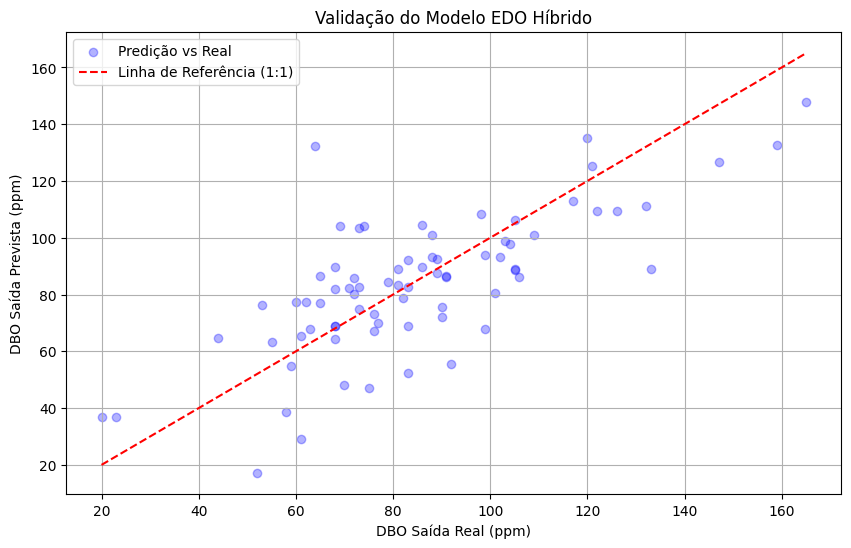

In [180]:
#Plot final
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.3, color='blue', label='Predição vs Real')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Linha de Referência (1:1)')
plt.title('Validação do Modelo EDO Híbrido')
plt.xlabel('DBO Saída Real (ppm)')
plt.ylabel('DBO Saída Prevista (ppm)')
plt.legend()
plt.grid(True)
plt.show()

In [181]:
# Organização dos resultados em um DataFrame para fácil visualização
parametros_df = pd.DataFrame({
    'Parametro': ['b0 (k20)', 'b1 (PC1)', 'b2 (PC2)', 'b3 (PC3)', 'b4 (PC4)', 'b5 (PC5)', 'b6 (PC6)', 'b7 (PC7)', 'b8 (PC8)'],
    'Valor_Otimizado': popt,
    'Erro_Padrao': perr,
    'P_Valor': p_values
})

# Exibição formatada
display(parametros_df)


# Salvando para facilitar no word pq tem que trocar . por,
"""
df_resultados_edo = pd.DataFrame({
    'Real': y,
    'Previsto_EDO': y_pred,
    'TDH': tdh # Assumindo que tdh foi calculado dentro da função ou globalmente
})
df_resultados_edo.to_csv('resultados_edo_hibrida.csv', index=False)
print("\nResultados salvos com sucesso em 'resultados_edo_hibrida.csv'")"""

,Parametro,Valor_Otimizado,Erro_Padrao,P_Valor
0,b0 (k20),0.214353,0.005840,0.000000
1,b1 (PC1),0.021185,0.019888,0.290669
2,b2 (PC2),-0.032001,0.014767,0.033843
3,b3 (PC3),-0.041425,0.020672,0.049182
4,b4 (PC4),0.017981,0.026003,0.491679
5,b5 (PC5),-0.070351,0.023949,0.004553
6,b6 (PC6),0.028401,0.027376,0.303319
7,b7 (PC7),0.019954,0.026179,0.448636
8,b8 (PC8),-0.106587,0.037140,0.005511


'\ndf_resultados_edo = pd.DataFrame({\n    \'Real\': y,\n    \'Previsto_EDO\': y_pred,\n    \'TDH\': tdh # Assumindo que tdh foi calculado dentro da função ou globalmente\n})\ndf_resultados_edo.to_csv(\'resultados_edo_hibrida.csv\', index=False)\nprint("\nResultados salvos com sucesso em \'resultados_edo_hibrida.csv\'")'

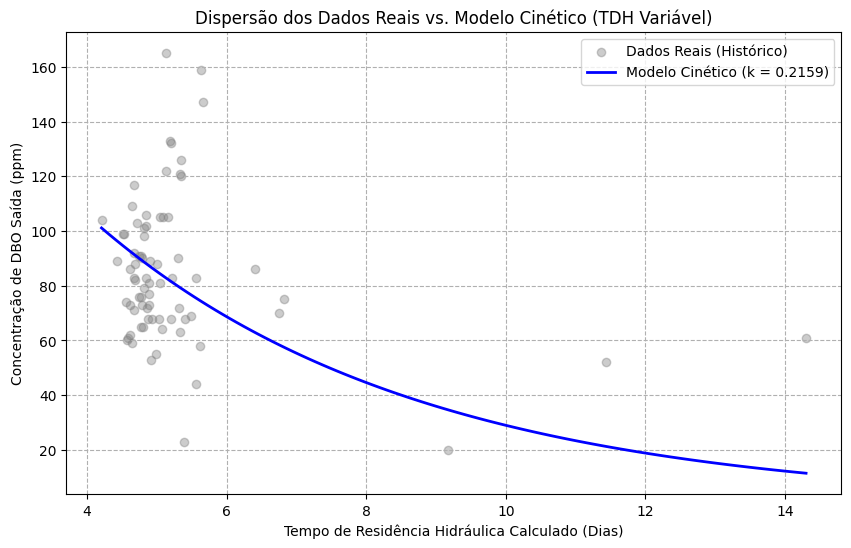

In [182]:
#Decaimento com EDO

# o vetor TDH real para cada ponto novamente
tdh_real = VOLUME_LAGOA / df['FRout(m3/dia)'].values

plt.figure(figsize=(10, 6))

# Dispersão usando o TDH real de cada amostra
plt.scatter(tdh_real,
            df['BODout(ppm)'].values,
            alpha=0.4, color='gray', label='Dados Reais (Histórico)')

# Curva do modelo cinético de referência
tdh_range = np.linspace(tdh_real.min(), tdh_real.max(), 100)
bod_in_media = np.mean(df['BODin (ppm)'])
y_modelo = bod_in_media * np.exp(-k_otimizado * tdh_range)

plt.plot(tdh_range, y_modelo, color='blue', linewidth=2, label=f'Modelo Cinético (k = {k_otimizado:.4f})')

plt.title('Dispersão dos Dados Reais vs. Modelo Cinético (TDH Variável)')
plt.xlabel('Tempo de Residência Hidráulica Calculado (Dias)')
plt.ylabel('Concentração de DBO Saída (ppm)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

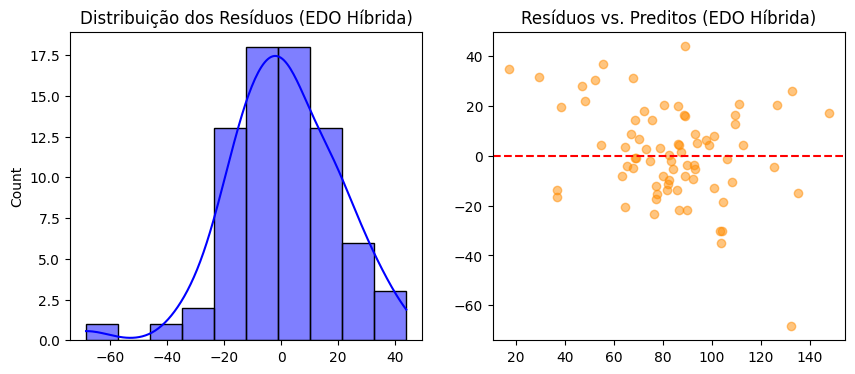

In [183]:
# Cálculo dos resíduos do Modelo Híbrido
residuos_hibrido = y - y_pred

plt.figure(figsize=(10, 4))

#Histograma
plt.subplot(1, 2, 1)
sns.histplot(residuos_hibrido, kde=True, color='blue')
plt.title('Distribuição dos Resíduos (EDO Híbrida)')

# Homocedasticidade
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuos_hibrido, alpha=0.5, color='darkorange')
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos vs. Preditos (EDO Híbrida)')
plt.show()

### Regressão de Componentes Principais

In [184]:
selecionadas.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'], dtype='object')

In [185]:
# Preparação da variável alvo (Linearização pelo logaritmo da DBO de saída)
y_mlr = np.log(df['BODout(ppm)'].values)

# Montagem da Matriz X APENAS com os PCs e a constante
X_mlr = pd.DataFrame({
    'const': 1,
    'PC1': selecionadas['PC1'],
    'PC2': selecionadas['PC2'],
    'PC3': selecionadas['PC3'],
    'PC4': selecionadas['PC4'],
    'PC5': selecionadas['PC5'],
    'PC6': selecionadas['PC6'],
    'PC7': selecionadas['PC7'],
    'PC8': selecionadas['PC8']
})

# Ajuste do modelo via statsmodels (para o summary)
modelo_ols = sm.OLS(y_mlr, X_mlr).fit()
print(modelo_ols.summary())

# Geração das previsões (retornando da escala logarítmica para ppm via exponencial)
y_pred_log = modelo_ols.predict(X_mlr)
y_pred_ppm = np.exp(y_pred_log)
y_real_ppm = df['BODout(ppm)'].values

# Métricas em escala real (PPM)
rmse = np.sqrt(mean_squared_error(y_real_ppm, y_pred_ppm))
r2 = r2_score(y_real_ppm, y_pred_ppm)
r2_adj = 1 - ((1 - r2) * (len(y_real_ppm) - 1) / (len(y_real_ppm) - X_mlr.shape[1] - 1))

print(f"\nRMSE: {rmse:.2f} ppm | R² Global: {r2*100:.2f}% | R² Ajustado: {r2_adj*100:.2f}%")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     18.01
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           6.12e-14
Time:                        13:22:59   Log-Likelihood:                 16.873
No. Observations:                  75   AIC:                            -15.75
Df Residuals:                      66   BIC:                             5.112
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3884      0.024    184.510      0.0

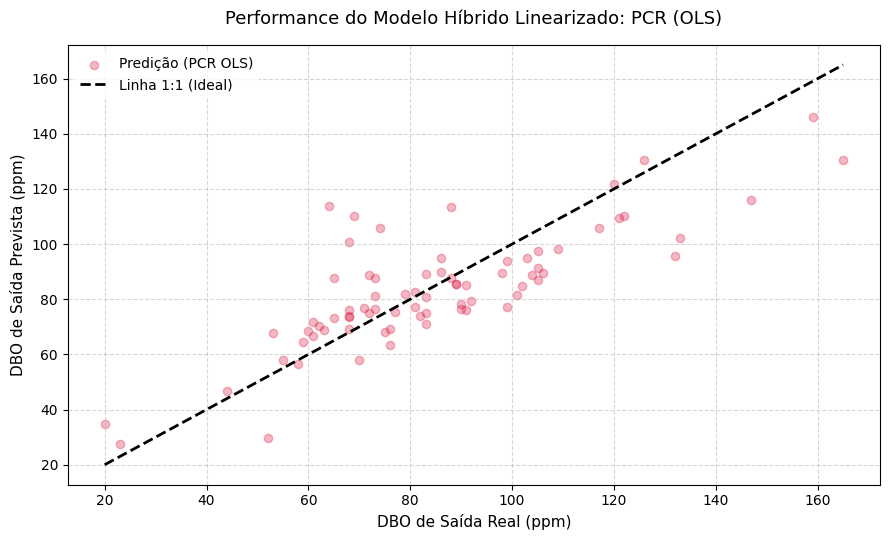

In [186]:
plt.figure(figsize=(9, 5.5))

# Plotando os pontos de dispersão real vs previsto
plt.scatter(y_real_ppm, y_pred_ppm, alpha=0.3, color='crimson', label='Predição (PCR OLS)')

# Adicionando a linha de referência ideal 1:1
min_val = min(y_real_ppm.min(), y_pred_ppm.min())
max_val = max(y_real_ppm.max(), y_pred_ppm.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Linha 1:1 (Ideal)')

# Ajustes de formatação visual para nível de artigo científico
plt.title('Performance do Modelo Híbrido Linearizado: PCR (OLS)', fontsize=13, pad=15)
plt.xlabel('DBO de Saída Real (ppm)', fontsize=11)
plt.ylabel('DBO de Saída Prevista (ppm)', fontsize=11)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle='--', alpha=0.5)

# Otimização de espaçamento de bordas
plt.tight_layout()
plt.show()

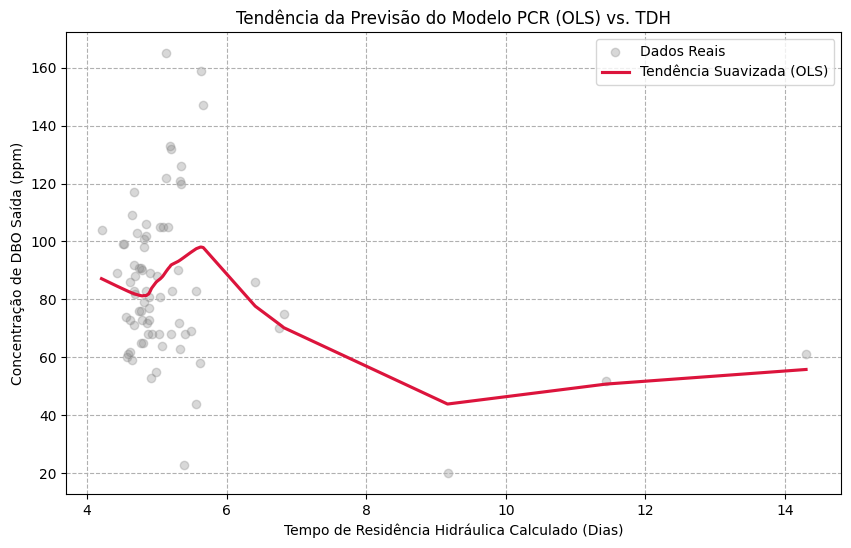

In [187]:
# Decaimento com RL

plt.figure(figsize=(10, 6))

#  Dados Reais
plt.scatter(tdh_real, df['BODout(ppm)'].values, alpha=0.3, color='gray', label='Dados Reais')


sns.regplot(x=tdh_real, y=y_pred_ppm, color='crimson',
            scatter=False, lowess=True, label='Tendência Suavizada (OLS)')

plt.title('Tendência da Previsão do Modelo PCR (OLS) vs. TDH')
plt.xlabel('Tempo de Residência Hidráulica Calculado (Dias)')
plt.ylabel('Concentração de DBO Saída (ppm)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

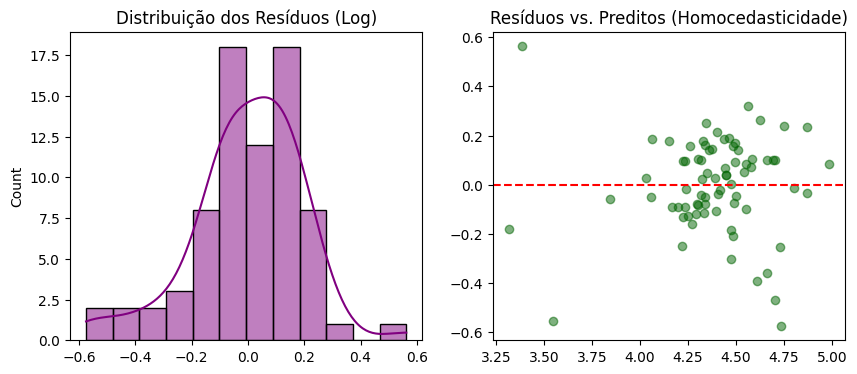

In [188]:
# Diagnóstico de Resíduos: Essencial para validar a PCR
residuos = y_mlr - y_pred_log

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, color='purple')
plt.title('Distribuição dos Resíduos (Log)')

plt.subplot(1, 2, 2)
plt.scatter(y_pred_log, residuos, alpha=0.5, color='darkgreen')
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos vs. Preditos (Homocedasticidade)')
plt.show()

Para comparar com a edo híbrida, precisamos tirar da escala logaritmica e voltar essa análise de resíduos para a escala real


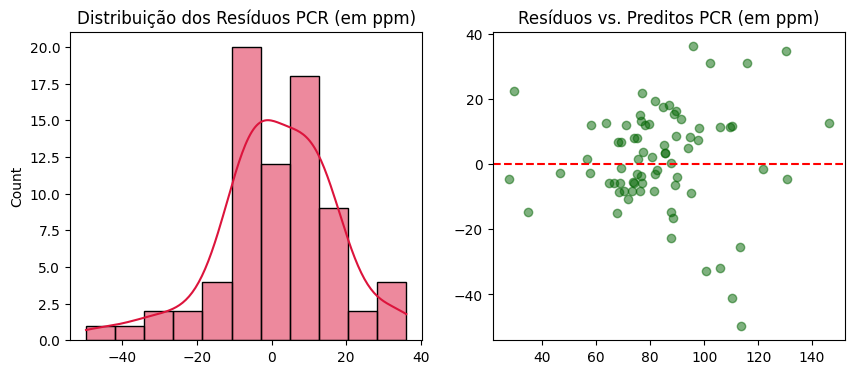

In [189]:
# Cálculo dos resíduos da PCR na escala REAL (PPM)
residuos_pcr_ppm = y_real_ppm - y_pred_ppm

plt.figure(figsize=(10, 4))

# Histograma em PPM
plt.subplot(1, 2, 1)
sns.histplot(residuos_pcr_ppm, kde=True, color='crimson')
plt.title('Distribuição dos Resíduos PCR (em ppm)')

# Homocedasticidade em PPM
plt.subplot(1, 2, 2)
plt.scatter(y_pred_ppm, residuos_pcr_ppm, alpha=0.5, color='darkgreen')
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos vs. Preditos PCR (em ppm)')
plt.show()

### Comparando os resultados (essa parte é para o artigo)

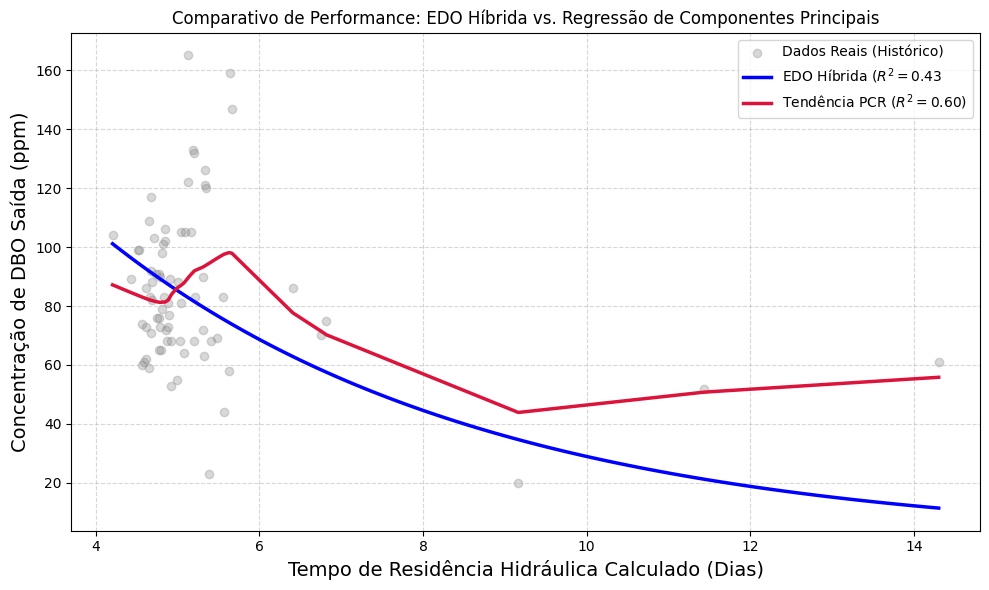

In [190]:

plt.figure(figsize=(10, 6))

# Dados Reais
plt.scatter(tdh_real, df['BODout(ppm)'].values, alpha=0.3, color='gray', label='Dados Reais (Histórico)')

# Modelo Cinético (EDO)
plt.plot(tdh_range, y_modelo, color='blue', linewidth=2.5,
         label=f'EDO Híbrida ($R^2={r2_adj_edo:.2f}$')

# PCR
sns.regplot(x=tdh_real, y=y_pred_ppm, color='crimson',
            scatter=False, lowess=True, label=f'Tendência PCR ($R^2={r2_adj:.2f}$)',
            line_kws={'linewidth': 2.5})

plt.title('Comparativo de Performance: EDO Híbrida vs. Regressão de Componentes Principais')
plt.xlabel('Tempo de Residência Hidráulica Calculado (Dias)',fontsize=14)
plt.ylabel('Concentração de DBO Saída (ppm)',fontsize=14)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

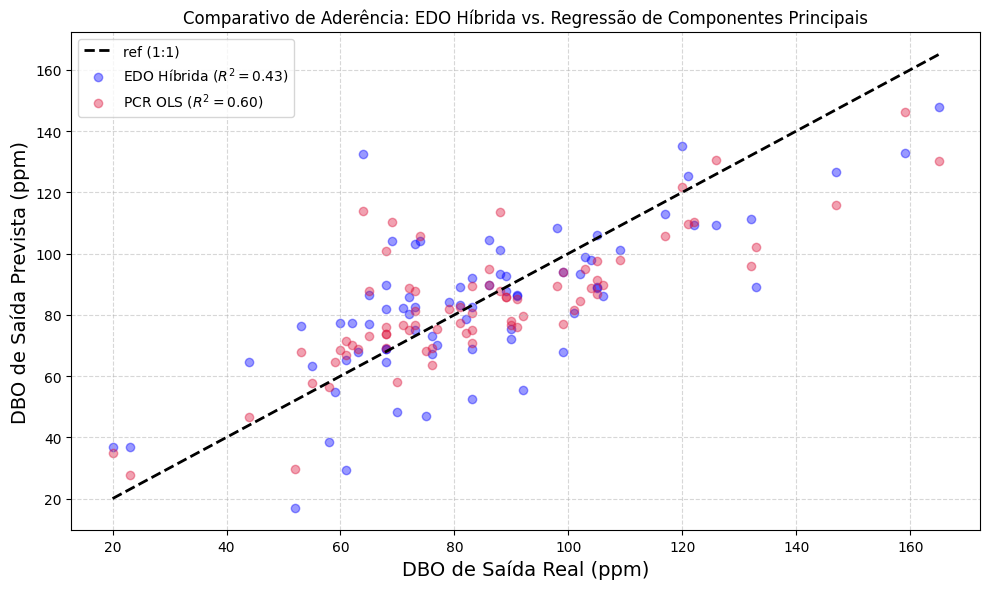

In [191]:
#comparando as predições dos modelos tbm

plt.figure(figsize=(10, 6))

#  Linha de referência 1:1
min_val = min(y.min(), y_real_ppm.min())
max_val = max(y.max(), y_real_ppm.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='ref (1:1)')

# Modelo EDO Híbrido
plt.scatter(y, y_pred, alpha=0.4, color='blue', label=f'EDO Híbrida ($R^2={r2_adj_edo:.2f}$)')

# Modelo Regressão Linear (OLS) (Vermelho)
plt.scatter(y_real_ppm, y_pred_ppm, alpha=0.4, color='crimson', label=f'PCR OLS ($R^2={r2_adj:.2f}$)')

plt.title('Comparativo de Aderência: EDO Híbrida vs. Regressão de Componentes Principais')
plt.xlabel('DBO de Saída Real (ppm)', fontsize=14)
plt.ylabel('DBO de Saída Prevista (ppm)',fontsize=14)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

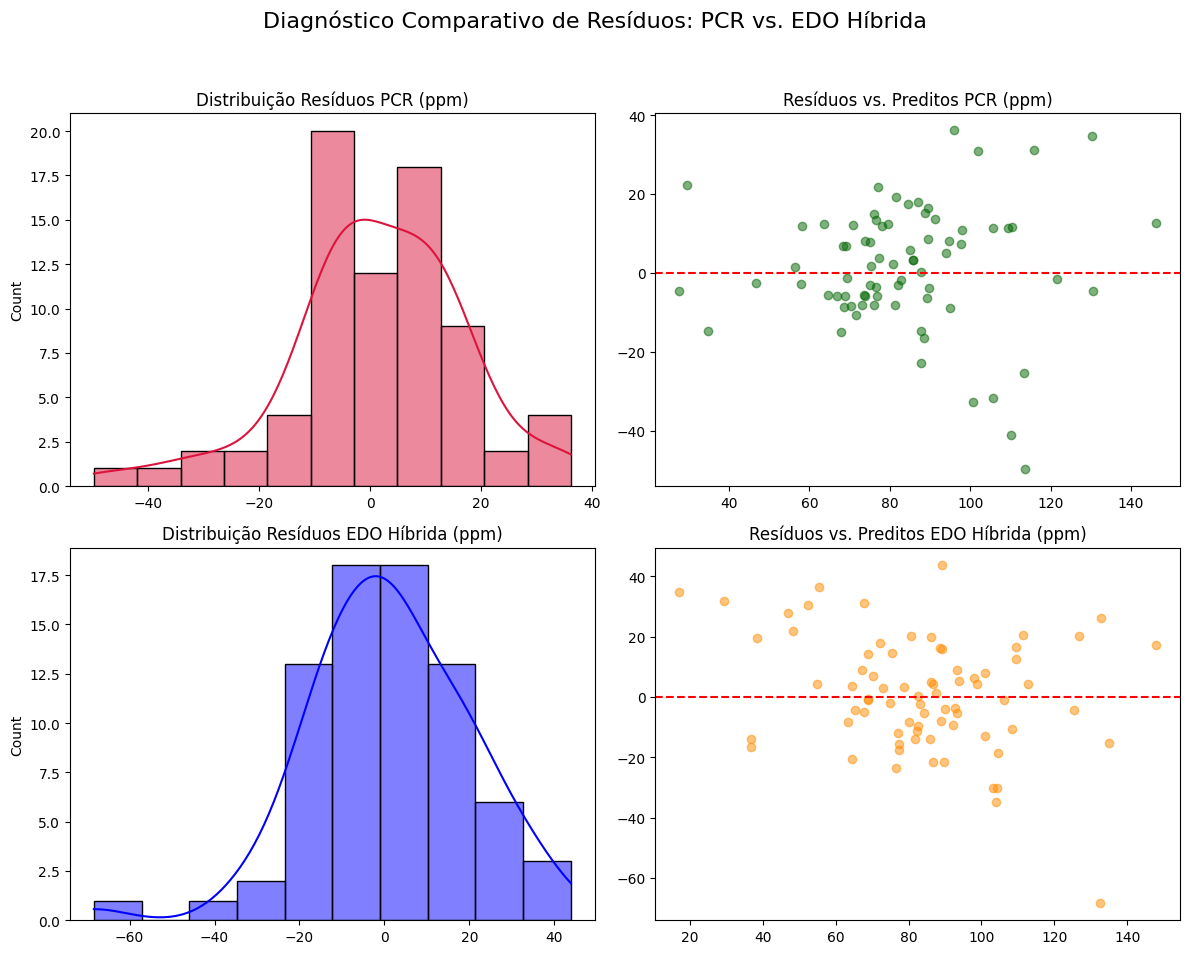

In [192]:

# Configuração da figura (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Diagnóstico Comparativo de Resíduos: PCR vs. EDO Híbrida', fontsize=16)

#PCR
residuos_pcr = y_real_ppm - y_pred_ppm

sns.histplot(residuos_pcr, kde=True, color='crimson', ax=axes[0, 0])
axes[0, 0].set_title('Distribuição Resíduos PCR (ppm)')

axes[0, 1].scatter(y_pred_ppm, residuos_pcr, alpha=0.5, color='darkgreen')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Resíduos vs. Preditos PCR (ppm)')

# EDO
residuos_edo = y - y_pred

sns.histplot(residuos_edo, kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição Resíduos EDO Híbrida (ppm)')

axes[1, 1].scatter(y_pred, residuos_edo, alpha=0.5, color='darkorange')
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('Resíduos vs. Preditos EDO Híbrida (ppm)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()